In [2]:
import ROOT as r 
import numpy as np 
from matplotlib import pyplot as plt

Welcome to JupyROOT 6.26/06


In [3]:
FlukaFilePMMA = r.TFile("outfile_final_PMMA.root", "READ")
flukatreePMMA = FlukaFilePMMA.Get("treevar")

FlukaFile = r.TFile("outfile_4x4.root", "READ")
flukatree = FlukaFile.Get("treevar")

## Estimate how many particles/cm^2 in each emulsion film

In [4]:
emu_layers_z = []
start_z = 2800-40 #micron, half of the ECC - 40

single_side_N = 20 #emulsion layers for z<0 and z>0

for i in range(single_side_N):
    if (i%2==0):
        start_z += 40
        emu_layers_z.append((start_z, start_z+40))
    else:
        start_z += 240
        emu_layers_z.append((start_z, start_z+40))

print(emu_layers_z)

[(2800, 2840), (3040, 3080), (3080, 3120), (3320, 3360), (3360, 3400), (3600, 3640), (3640, 3680), (3880, 3920), (3920, 3960), (4160, 4200), (4200, 4240), (4440, 4480), (4480, 4520), (4720, 4760), (4760, 4800), (5000, 5040), (5040, 5080), (5280, 5320), (5320, 5360), (5560, 5600)]


In [5]:
n_intervals = np.zeros(len(emu_layers_z))
n_intervals_PMMA = np.zeros(len(emu_layers_z))
for event_particle in flukatree:
    for j, interval in enumerate(emu_layers_z):
        if (10000*event_particle.iz<=interval[0] and 10000*event_particle.fz>=interval[1] and event_particle.Z>0):
            n_intervals[j] += 1

for event_particle in flukatreePMMA:
    for j, interval in enumerate(emu_layers_z):
        if (10000*event_particle.iz<=interval[0] and 10000*event_particle.fz>=interval[1] and event_particle.Z>0):
            n_intervals_PMMA[j] += 1
print(n_intervals)

[ 769.  797.  808.  897.  907.  957.  970. 1022. 1027. 1084. 1118. 1161.
 1161. 1217. 1218. 1260. 1273. 1311. 1330. 1373.]


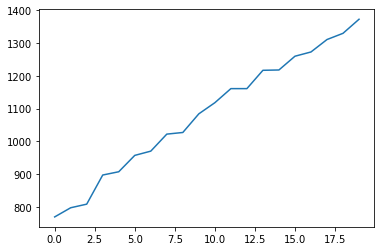

In [6]:
plt.plot(n_intervals)
plt.show()

[(2800, 2840), (2560, 2600), (2520, 2560), (2280, 2320), (2240, 2280), (2000, 2040), (1960, 2000), (1720, 1760), (1680, 1720), (1440, 1480), (1400, 1440), (1160, 1200), (1120, 1160), (880, 920), (840, 880), (600, 640), (560, 600), (320, 360), (280, 320), (40, 80)]
[769. 679. 663. 610. 594. 507. 492. 427. 407. 324. 316. 230. 217. 145.
 128.  35.   9.   0.   0.   0.]


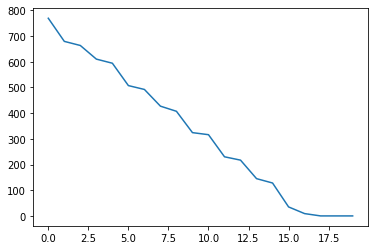

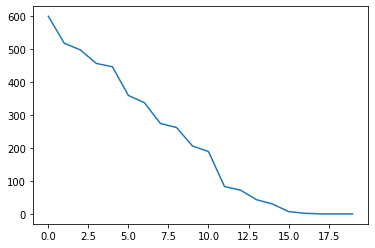

In [11]:
emu_layers_z = []
start_z = 2800 + 40 #micron, half of ECC + 40

single_side_N = 20 #emulsion layers for z<0 and z>0

for i in range(single_side_N):
    if (i%2==0):
        start_z -= 40
        emu_layers_z.append((start_z, start_z+40))
    else:
        start_z -= 240
        emu_layers_z.append((start_z, start_z+40))

print(emu_layers_z)

n_intervals2 = np.zeros(len(emu_layers_z))
n_intervals2_PMMA = np.zeros(len(emu_layers_z))
for event_particle in flukatree:
    for j, interval in enumerate(emu_layers_z):
        if (10000*event_particle.iz<=interval[0] and 10000*event_particle.fz>=interval[1] and event_particle.Z>0):
            n_intervals2[j] += 1

for event_particle in flukatreePMMA:
    for j, interval in enumerate(emu_layers_z):
        if (10000*event_particle.iz<=interval[0] and 10000*event_particle.fz>=interval[1] and event_particle.Z>0):
            n_intervals2_PMMA[j] += 1
print(n_intervals2)

plt.plot(n_intervals2)
plt.show()

plt.plot(n_intervals2_PMMA)
plt.show()

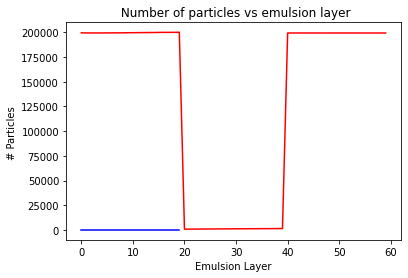

In [8]:
unique_list = []
n_intervals_list2 = list(n_intervals2)
n_intervals_list2.reverse()

for i in range(single_side_N):
    unique_list.append(n_intervals_list2[i])
for i in range(single_side_N):
    unique_list.append(n_intervals[i])

unique_list_PMMA = []
n_intervals_list2_PMMA = list(n_intervals2_PMMA)
n_intervals_list2_PMMA.reverse()

for i in range(single_side_N):
    unique_list_PMMA.append(n_intervals_list2_PMMA[i])
for i in range(single_side_N):
    unique_list.append(n_intervals_PMMA[i])


plt.plot(unique_list, color='r')
plt.plot(unique_list_PMMA, color='b')
plt.xlabel("Emulsion Layer")
plt.ylabel("# Particles ")
plt.title(" Number of particles vs emulsion layer")
plt.show()

In [8]:
print(len(unique_list))
print(sum(unique_list))
print(unique_list)

36
19924.0
[15.0, 110.0, 133.0, 184.0, 207.0, 269.0, 275.0, 323.0, 338.0, 365.0, 371.0, 437.0, 462.0, 497.0, 512.0, 542.0, 547.0, 583.0, 583.0, 598.0, 607.0, 639.0, 642.0, 684.0, 701.0, 725.0, 734.0, 770.0, 788.0, 835.0, 837.0, 885.0, 883.0, 927.0, 934.0, 982.0]
